In [5]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.image import imread
from IPython.display import display, clear_output, Image

In [6]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371000  
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi/2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

def get_local_path(root_folder, original_linux_path):
    """
    Strips the first 4 directories from the Ubuntu path and joins with the Windows root.
    Example: /vol2/Amfitrite/OWD/obis_data_v2/HABs_part1/folder -> root_folder/HABs_part1/folder
    """
    # Split by the linux separator
    parts = original_linux_path.strip().strip('/').split('/')
    # Remove the first 4 parts (e.g., vol2, Amfitrite, OWD, obis_data_v2)
    kept_parts = parts[4:]
    # Join using os.path to safely handle Windows backslashes
    return os.path.join(root_folder, *kept_parts)

def parse_user_tiles(user_input, valid_tile_dict):
    """Converts user input like '1, 3, 5' into actual folder names."""
    if not user_input.strip():
        return []
    
    selected_names = []
    # Split by comma and clean whitespace
    raw_nums = [n.strip() for n in user_input.split(',')]
    
    for num in raw_nums:
        if num in valid_tile_dict:
            selected_names.append(valid_tile_dict[num])
        else:
            print(f"  [!] Warning: Tile '{num}' not found. Skipping.")
            
    return selected_names

In [7]:
def run_annotation_ui(root_folder, csv_path, focus_choice="HAB"):
    if not os.path.exists(csv_path):
        print(f"Error: CSV not found at {csv_path}")
        return
        
    df = pd.read_csv(csv_path, low_memory=False)
    
    # Filename Logic (Don't overwrite the original unless it's already the processed version)
    if csv_path.endswith("_processed.csv"):
        save_path = csv_path
    else:
        save_path = csv_path.replace(".csv", "_processed.csv")
        
    # Column Initialization
    for col in ['manually_processed', 'usable', 'tiles_HABs', 'tiles_nonHABs']:
        if col not in df.columns:
            df[col] = 0 if col in ['manually_processed', 'usable'] else ""
            
    col_status = 'status'
    col_ishab = 'is_HAB'
    col_outfolder = 'output_folder'
    col_lat = 'latitiude'
    col_lon = 'Longtitude'
    col_ocl = "Overall_Class"
    
    target_ishab = 'YES' if focus_choice.upper() == 'HAB' else 'NO'
    
    # Dynamic Clustering if missing
    if 'cluster_ID' not in df.columns:
        print("Column 'cluster_ID' not found. Generating spatial clusters dynamically...")
        df['cluster_ID'] = np.nan
        # EXCLUDE 'filters removed all tiles'
        df_success = df[(df[col_status].astype(str).str.upper() == 'SUCCESS') & 
                        (df[col_ocl].astype(str).str.lower() != 'filters removed all tiles')]
        c_count = 1
        for idx, row in df_success.iterrows():
            if pd.notna(df.at[idx, 'cluster_ID']): continue
            mask = haversine_distance(row[col_lat], row[col_lon], df_success[col_lat], df_success[col_lon]) <= 7680
            df.loc[df_success[mask].index, 'cluster_ID'] = c_count
            c_count += 1
            
    # Find all clusters that have at least one unprocessed target entry
    target_mask = (df[col_ishab].astype(str).str.strip().str.upper() == target_ishab)
    unprocessed_mask = (df['manually_processed'] != 1) & (df['manually_processed'].astype(str).str.upper() != 'YES')
    
    # EXCLUDE 'filters removed all tiles'
    valid_clusters = df[target_mask & unprocessed_mask & 
                        (df[col_status].astype(str).str.upper() == 'SUCCESS') & 
                        (df[col_ocl].astype(str).str.lower() != 'filters removed all tiles')]['cluster_ID'].dropna().unique()

    if len(valid_clusters) == 0:
        print("No remaining unprocessed cases match your criteria! You are all done.")
        return

    # Iterate through valid clusters
    for cid in valid_clusters:
        cluster_entries = df[(df['cluster_ID'] == cid) & 
                             (df[col_status].astype(str).str.upper() == 'SUCCESS') & 
                             (df[col_ocl].astype(str).str.lower() != 'filters removed all tiles') & 
                             unprocessed_mask]
        
        hab_count = sum(cluster_entries[col_ishab].astype(str).str.strip().str.upper() == 'YES')
        nonhab_count = sum(cluster_entries[col_ishab].astype(str).str.strip().str.upper() == 'NO')
        
        for idx, row in cluster_entries.iterrows():
            clear_output(wait=True)
            print("="*80)
            print(f"CLUSTER {cid} | Remaining in cluster: {hab_count} HABs, {nonhab_count} non-HABs")
            print("="*80)
            print(f"--- Evaluating Entry ---")
            print(f"is_HAB Database Status: {row[col_ishab]}")
            
            local_base_folder = get_local_path(root_folder, row[col_outfolder])
            
            # Locate summary file (.csv or .xlsx)
            summary_path_csv = os.path.join(local_base_folder, "folder_summary_v2.csv")
            summary_path_xlsx = os.path.join(local_base_folder, "folder_summary_v2.xlsx")
            
            df_summary = None
            if os.path.exists(summary_path_csv):
                df_summary = pd.read_csv(summary_path_csv)
            elif os.path.exists(summary_path_xlsx):
                df_summary = pd.read_excel(summary_path_xlsx)
                
            tile_map = {}
                
            if df_summary is not None and not df_summary.empty:
                # Based on your uploaded CSV, find valid tiles
                valid_tiles = df_summary[
                    (df_summary['Total_pixels'] == 65536) & 
                    (df_summary['SCL_Water_Pixels'] >= 32000)
                ].copy()
                
                rejected_tiles = df_summary[~df_summary.index.isin(valid_tiles.index)]
                
                print("\nTILE ANALYSIS:")
                if valid_tiles.empty:
                    print("  [!] Filters removed all tiles (Insufficient Water Pixels).")
                else:
                    for _, tile in valid_tiles.iterrows():
                        tile_name = str(tile['Tile_Folder'])
                        
                        # Extract the tile number (e.g., 'tile_1_H0...' -> '1')
                        try:
                            t_num = tile_name.split('_')[1]
                            tile_map[t_num] = tile_name
                        except IndexError:
                            t_num = tile_name
                            tile_map[t_num] = tile_name
                        
                        def is_yes(col_name):
                            return str(tile.get(col_name, '')).strip().upper() == 'YES'
                            
                        rdnet_yes = is_yes('rdnet_no_scl')
                        cnn_cols = ['rdnet_no_scl', 'convnext_scl', 'res18_scl', 'res18_no_scl']
                        yes_count = sum(1 for c in cnn_cols if is_yes(c))
                        
                        cnn_score = sum([30 if is_yes('rdnet_no_scl') else 0,
                                         10 if is_yes('convnext_scl') else 0,
                                         10 if is_yes('res18_scl') else 0,
                                         10 if is_yes('res18_no_scl') else 0])
                        
                        cyfi_high = float(tile.get('CyFi_High', 0))
                        cyfi_mod = float(tile.get('CyFi_Moderate', 0))
                        cyfi_low = float(tile.get('CyFi_Low', 0))
                        water_pixels = tile.get('SCL_Water_Pixels', 0)
                        
                        cyfi_score = ((cyfi_high + (0.5 * cyfi_mod)) / 676.0) * 40.0
                        total_index = round(cnn_score + cyfi_score, 2) 
                        
                        is_hab_tile = rdnet_yes and (yes_count >= 2) and (cyfi_high >= 20)
                        is_clean_tile = (not rdnet_yes) and (yes_count <= 1) and (cyfi_high < 5) and (cyfi_mod < 15)
                        
                        if is_hab_tile: classification = "HAB"
                        elif is_clean_tile: classification = "CLEAR"
                        else: classification = "TO BE CHECKED"
                        
                        # Fetch individual CNN outputs
                        r18_s = tile.get('res18_scl', 'N/A')
                        r18_ns = tile.get('res18_no_scl', 'N/A')
                        conv_s = tile.get('convnext_scl', 'N/A')
                        rdnet_ns = tile.get('rdnet_no_scl', 'N/A')
                            
                        print(f"  [{t_num}] {tile_name} | Score: {total_index} | Class: {classification}")
                        print(f"      ↳ Water: {water_pixels} | CyFi [H:{cyfi_high}, M:{cyfi_mod}, L:{cyfi_low}] | CNN [res18_scl:{r18_s}, res18_ns:{r18_ns}, conv_scl:{conv_s}, rdnet_ns:{rdnet_ns}]")
                
                if not rejected_tiles.empty:
                    print("\nREJECTED TILES:")
                    for _, r_tile in rejected_tiles.iterrows():
                        t_name = r_tile['Tile_Folder']
                        t_water = r_tile.get('SCL_Water_Pixels', 0)
                        
                        # Fetch rejected tile stats
                        c_high = r_tile.get('CyFi_High', 0)
                        c_mod = r_tile.get('CyFi_Moderate', 0)
                        c_low = r_tile.get('CyFi_Low', 0)
                        r18_s = r_tile.get('res18_scl', 'N/A')
                        r18_ns = r_tile.get('res18_no_scl', 'N/A')
                        conv_s = r_tile.get('convnext_scl', 'N/A')
                        rdnet_ns = r_tile.get('rdnet_no_scl', 'N/A')
                        
                        print(f"  {t_name} | Rejected: SCL_Water_Pixels = {t_water} (< 32000)")
                        print(f"      ↳ CyFi [H:{c_high}, M:{c_mod}, L:{c_low}] | CNN [res18_scl:{r18_s}, res18_ns:{r18_ns}, conv_scl:{conv_s}, rdnet_ns:{rdnet_ns}]")
            else:
                print("\n[!] No folder_summary file found in this directory.")
                
            # --- SHOW IMAGE ---
            img_path = os.path.join(local_base_folder, "colage.png")
            if os.path.exists(img_path):
                display(Image(filename=img_path))
            else:
                print(f"\n[!] colage.png not found at {img_path}")
                
            # --- GET USER INPUT ---
            print("-" * 50)
            hab_input = input("Which tiles are HABs? (comma-separated numbers, or press Enter for none): ")
            nonhab_input = input("Which tiles are non-HABs? (comma-separated numbers, or press Enter for none): ")
            
            hab_folders = parse_user_tiles(hab_input, tile_map)
            nonhab_folders = parse_user_tiles(nonhab_input, tile_map)
            
            # --- UPDATE DATAFRAME ---
            df.at[idx, 'tiles_HABs'] = ", ".join(hab_folders)
            df.at[idx, 'tiles_nonHABs'] = ", ".join(nonhab_folders)
            df.at[idx, 'manually_processed'] = 1
            df.at[idx, 'usable'] = 1 if (hab_folders or nonhab_folders) else 0
            
            # Save incrementally
            df.to_csv(save_path, index=False)
            
        # Ask to quit after each full cluster is processed
        quit_choice = input(f"\nCluster {cid} complete. Do you want to quit? (yes/no): ").strip().lower()
        if quit_choice == 'yes' or quit_choice == 'y':
            print(f"Progress saved to {save_path}. Exiting.")
            return

    print(f"\nAll targeted cases have been annotated! Final data saved to {save_path}.")

CLUSTER 2 | Remaining in cluster: 1 HABs, 0 non-HABs
--- Evaluating Entry ---
is_HAB Database Status: Yes

TILE ANALYSIS:
  [0] tile_0_H0_M106_L389 | Score: 23.14 | Class: TO BE CHECKED
      ↳ Water: 48980 | CyFi [H:0.0, M:106.0, L:389.0] | CNN [res18_scl:NO, res18_ns:YES, conv_scl:YES, rdnet_ns:NO]
  [4] tile_4_H0_M0_L676 | Score: 0.0 | Class: CLEAR
      ↳ Water: 65536 | CyFi [H:0.0, M:0.0, L:676.0] | CNN [res18_scl:NO, res18_ns:NO, conv_scl:NO, rdnet_ns:NO]
  [5] tile_5_H0_M0_L676 | Score: 0.0 | Class: CLEAR
      ↳ Water: 65536 | CyFi [H:0.0, M:0.0, L:676.0] | CNN [res18_scl:NO, res18_ns:NO, conv_scl:NO, rdnet_ns:NO]
  [6] tile_6_H0_M0_L676 | Score: 0.0 | Class: CLEAR
      ↳ Water: 65536 | CyFi [H:0.0, M:0.0, L:676.0] | CNN [res18_scl:NO, res18_ns:NO, conv_scl:NO, rdnet_ns:NO]
  [7] tile_7_H0_M0_L642 | Score: 0.0 | Class: CLEAR
      ↳ Water: 63184 | CyFi [H:0.0, M:0.0, L:642.0] | CNN [res18_scl:NO, res18_ns:NO, conv_scl:NO, rdnet_ns:NO]

REJECTED TILES:
  tile_1 | Rejected: SCL_

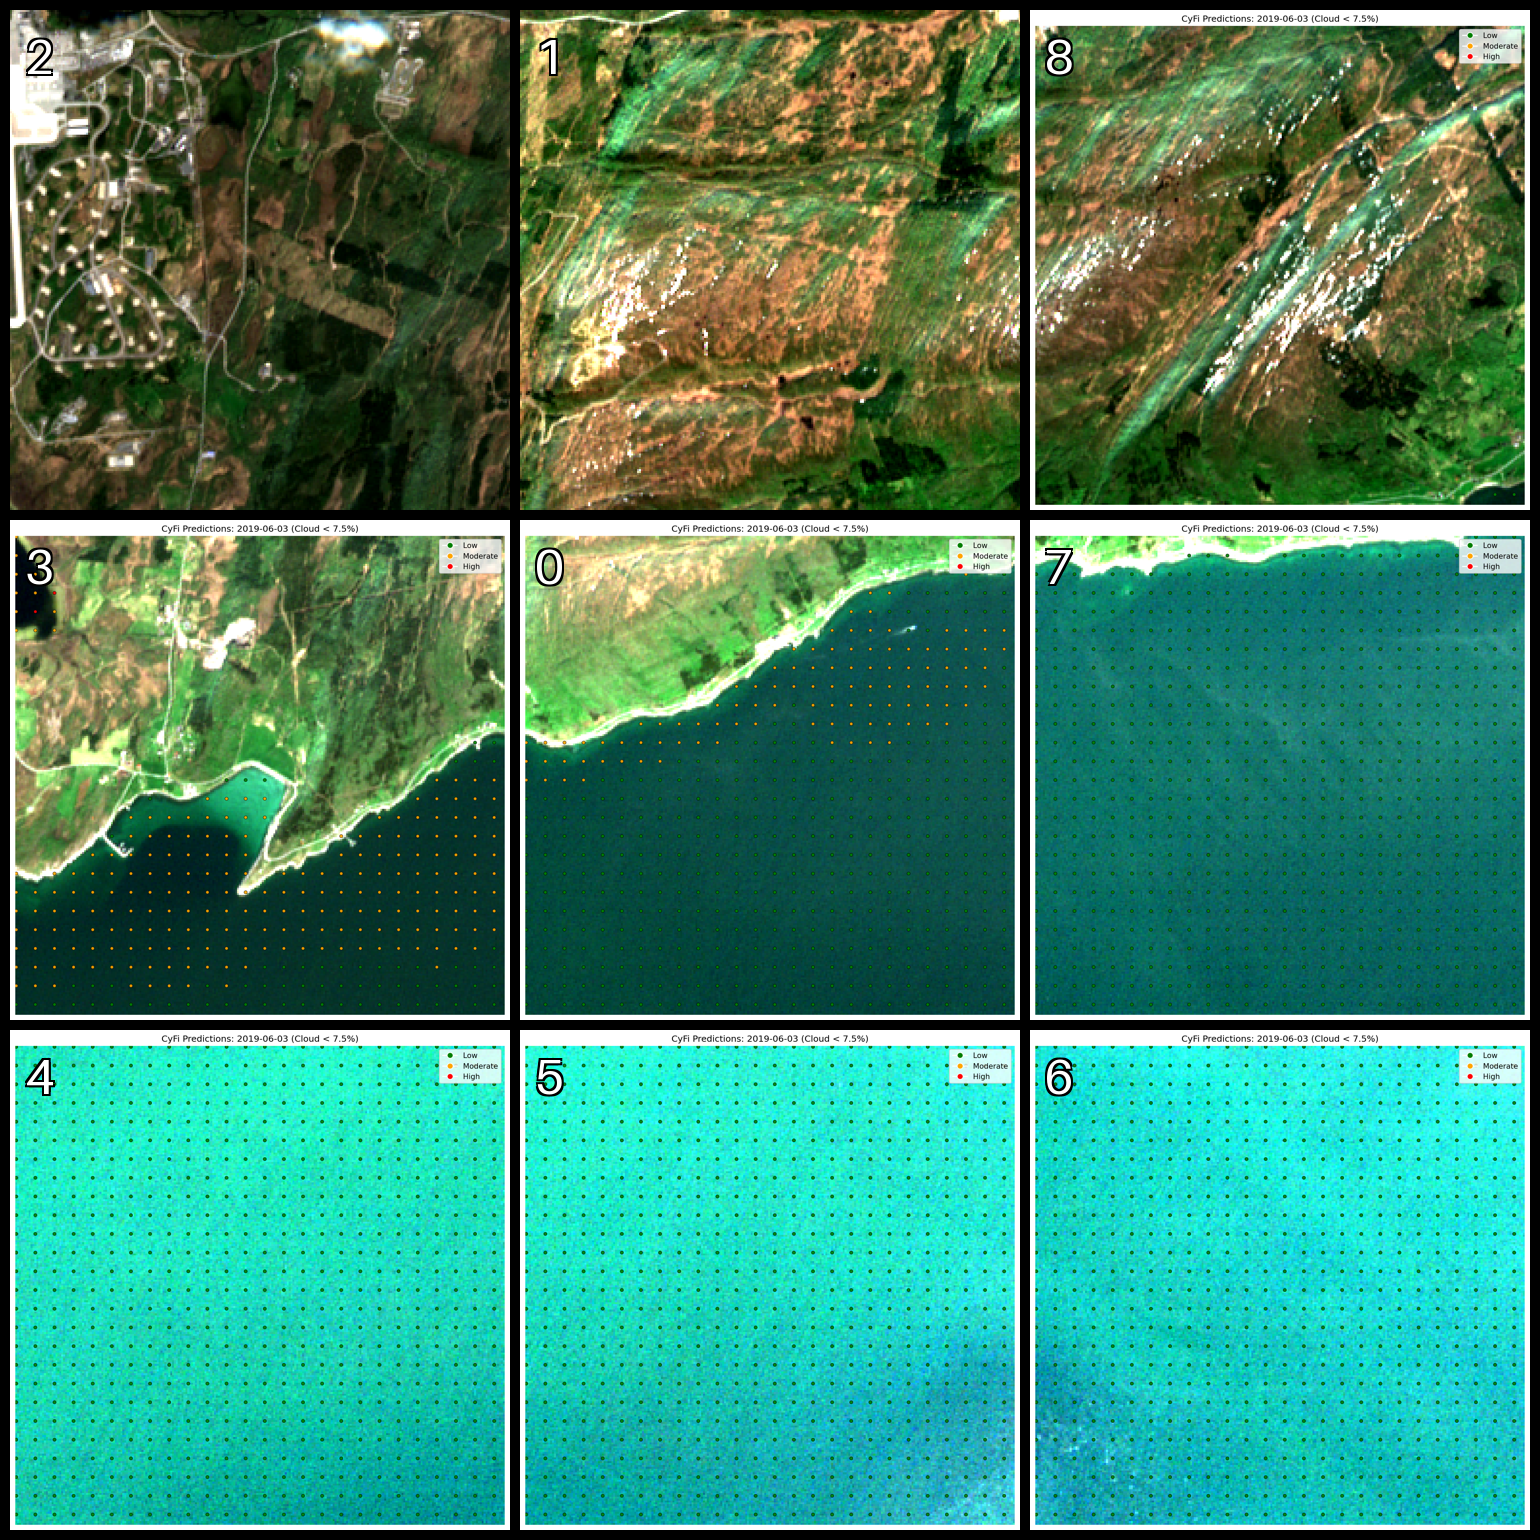

--------------------------------------------------


In [ ]:
root_folder = r"C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\OWD\Iains dataset\metadata"
csv_path = r"C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\OWD\Iains dataset\pre_processed_v3_priority_FINAL_with_results.csv"
focus_choice = "HAB"
run_annotation_ui(root_folder, csv_path, focus_choice)